## Assignment 01 - EN3160
### Fernando H.M.D. - 230180F

Question 01

In [28]:
# Intensity transformation functions
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\Assignment 1\images\q1.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [29]:
def intensity_transform(im, breakpoints):

    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    im_float = im.astype(np.float32)
    transformed = np.zeros_like(im_float)

    # Piecewise linear interpolation
    lut = np.zeros(256, dtype=np.float32)

    intensity_values = np.arange(256, dtype=np.float32)

    # Process each pair of consecutive breakpoints
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        if x1 == x2:
            continue

        # Intensities lying on this segment
        mask = (
            (intensity_values >= x1) &
            (intensity_values <= x2)
        )

        lut[mask] = (
            y1
            + (y2 - y1) *
            (intensity_values[mask] - x1) /
            (x2 - x1)
        )
        
    # At repeated x-values, use the value AFTER the jump
    for i in range(len(breakpoints) - 1):
        if x[i] == x[i + 1]:
            jump_x = int(x[i])
            lut[jump_x] = y[i + 1]

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return lut[im]


In [30]:

breakpoints = np.array([
    [0,   0],
    [50,  50],
    [50, 100],
    [150, 255],
    [150, 150],
    [200, 200],
    [255, 255]
])

transformed = intensity_transform(img, breakpoints)


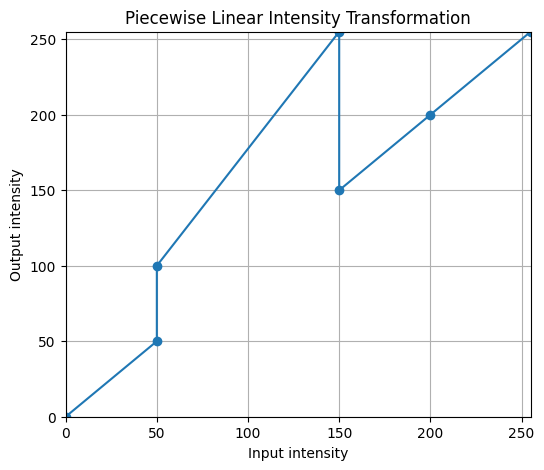

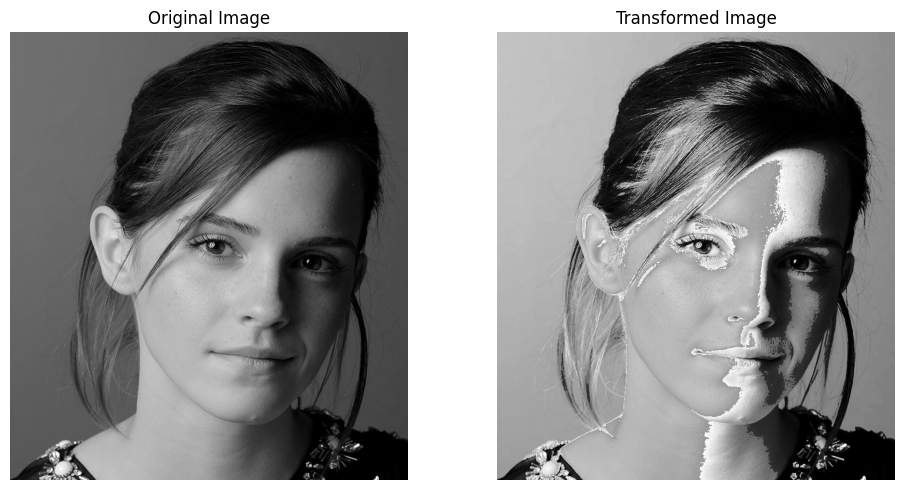

In [31]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    marker='o'
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

For a visually pleasing output

In [34]:

breakpoints = np.array([
    [0,   0],
    [50,  50],
    [100, 100],
    [150, 150],
    [255, 255]
])

transformed = intensity_transform(img, breakpoints)

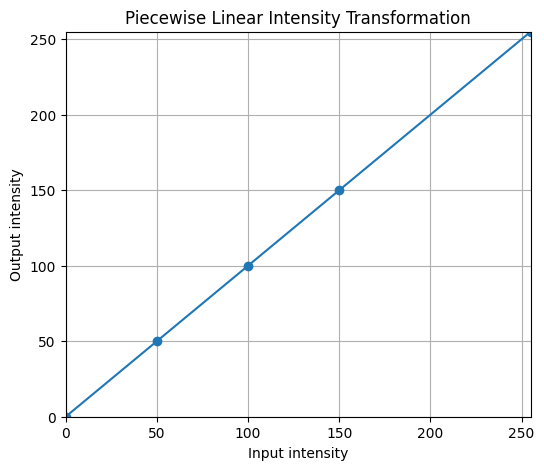

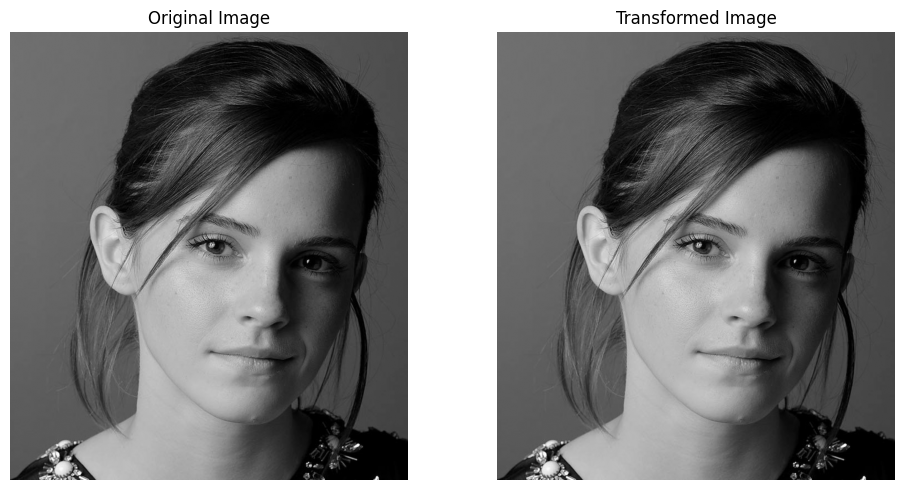

In [35]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    marker='o'
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()